<a href="https://colab.research.google.com/github/ERA-Software/computational-data-analysis/blob/main/notebooks/S9_introduction_to_drl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Reinforcement Learning — a hands-on tour 🤖


In 3 short acts you'll **run** the whole arc of the lecture yourself:

1. **The RL framework** — drive an environment and watch the state→action→reward loop.
2. **Q-Learning** — train a value **table** from scratch and watch value flow backward to the goal.
3. **Deep Q-Learning (DQN)** — when the table no longer fits, swap it for a neural network and train a real agent.

> **How to use this notebook.** Run the cells top to bottom (`Shift+Enter`). It is built for
> **Google Colab** — no local setup. A few cells are marked **✏️ Exercise**: try them before
> revealing the solution. Everything runs on a **CPU in a few minutes** (no GPU needed). You'll
> **see** every environment and watch agents play as animated GIFs.blockquote

One idea ties it all together — *learn from trial, error, and reward*. The same idea plays
Atari from pixels, controls robots, and aligns large language models (**RLHF**).

## Block 0 · Setup

In [ ]:
# Core libraries. gymnasium = the environments (+ rendering), stable-baselines3 = the deep RL algorithms.
# (Box2D for the closing Lunar Lander demo is installed later, only when needed.)
%pip install -q "gymnasium[classic-control,toy-text]" "stable-baselines3>=2.0" imageio

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import imageio
from IPython.display import Image, display

rng = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (7, 4)
print("gymnasium", gym.__version__)

gymnasium 1.3.0


We'll reuse two small helpers throughout to **see** the environments and **watch** episodes.
`show_env` draws a single frame; `play_episode` rolls out a policy and returns an animated GIF.
A `policy` is just a function `state -> action` (pass `policy=None` for a random agent).

In [ ]:
def show_env(env_id, title="", **make_kwargs):
    """Render and display a single frame of an environment."""
    env = gym.make(env_id, render_mode="rgb_array", **make_kwargs)
    env.reset(seed=0)
    frame = env.render()
    env.close()
    plt.figure(figsize=(4, 4)); plt.imshow(frame); plt.axis("off")
    if title: plt.title(title)
    plt.show()

def play_episode(env_id, policy=None, path="episode.gif", seed=0,
                 max_steps=500, fps=30, **make_kwargs):
    """Roll out `policy` for one episode and save/return an animated GIF."""
    env = gym.make(env_id, render_mode="rgb_array", **make_kwargs)
    obs, _ = env.reset(seed=seed)
    frames = [env.render()]
    for _ in range(max_steps):
        action = env.action_space.sample() if policy is None else policy(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        if terminated or truncated:
            break
    env.close()
    # loop=0 => loop forever (without it the GIF plays once and freezes, looking static);
    # duration is milliseconds per frame.
    imageio.mimsave(path, frames, format="GIF", duration=1000 / fps, loop=0)
    return Image(filename=path)

# 1 · The Reinforcement Learning framework

RL is **learning by interaction**: an *agent* takes an **action**, the *environment* answers
with a new **state** and a number — the **reward** — and the agent adjusts to collect more reward.
There is no labelled dataset of correct moves, only the consequences of its own choices.

![The RL loop: state → action → reward → next state](https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit1/RL_process_game.jpg)

We'll make every piece of this loop concrete on a classic control task: **CartPole** — balance a
pole on a moving cart. Let's create it, *look* at it, and *interrogate* it.

In [ ]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=0)

print("Observation space :", env.observation_space)   # what the agent SEES
print("Action space      :", env.action_space)        # what the agent can DO
print("First observation :", np.round(obs, 3))

Observation space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space      : Discrete(2)
First observation : [ 0.014 -0.023 -0.046 -0.048]


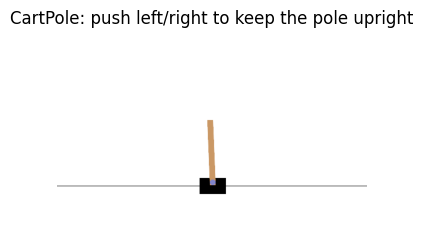

In [ ]:
show_env("CartPole-v1", title="CartPole: push left/right to keep the pole upright")

**State vs observation, and the Markov property.** The observation is 4 numbers —
`[cart position, cart velocity, pole angle, pole angular velocity]`. That is the *complete*
description needed to decide the next move: no memory of the past is required. A loop with this
**Markov property** is a **Markov Decision Process (MDP)** — the formal object all of RL studies.

**Action space.** `Discrete(2)` → exactly two actions: push the cart **left (0)** or **right (1)**.
A *finite* set of choices. Q-Learning and DQN — today's focus — target **discrete** action spaces.
(Continuous control, e.g. a steering angle, needs other methods we mention at the end.)

In [ ]:
# One step of the loop: take an action, receive (next_state, reward, terminated, truncated, info).
action = env.action_space.sample()                 # a random action for now (no policy yet)
next_obs, reward, terminated, truncated, info = env.step(action)
print(f"action={action}  reward={reward}  terminated={terminated}  truncated={truncated}")
print("next observation:", np.round(next_obs, 3))

action=0  reward=1.0  terminated=False  truncated=False
next observation: [ 0.013 -0.217 -0.047  0.23 ]


**The trajectory and the reward hypothesis.** Repeating this produces a stream
$S_0, A_0, R_1, S_1, A_1, R_2, \dots$ — a *trajectory*. CartPole gives **+1 for every step the
pole stays up**, so the episode reward is just *how long you balanced*. This is the
**reward hypothesis**: *every goal can be framed as maximising expected cumulative reward.*

Let's run one full episode with a **random policy** — printing the start of the stream and watching
it play. The episode ends (`terminated`) when the pole falls — CartPole is an **episodic** task
(it has a terminal state), unlike a **continuing** task that never stops.

In [ ]:
obs, info = env.reset(seed=1)
total_reward = 0.0
for t in range(500):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    if t < 5:
        print(f"t={t}: action={action} -> reward={reward}, next_state={np.round(obs,2)}")
    if terminated or truncated:
        break
print(f"\nRandom policy balanced for {t+1} steps (episode reward = {total_reward}).")

t=0: action=0 -> reward=1.0, next_state=[ 0.   -0.15 -0.03  0.33]
t=1: action=0 -> reward=1.0, next_state=[-0.   -0.34 -0.03  0.61]
t=2: action=1 -> reward=1.0, next_state=[-0.01 -0.15 -0.02  0.31]
t=3: action=0 -> reward=1.0, next_state=[-0.01 -0.34 -0.01  0.59]
t=4: action=1 -> reward=1.0, next_state=[-0.02 -0.15  0.    0.3 ]

Random policy balanced for 17 steps (episode reward = 17.0).


Now watch that random policy — it flails and drops the pole within a second or two:

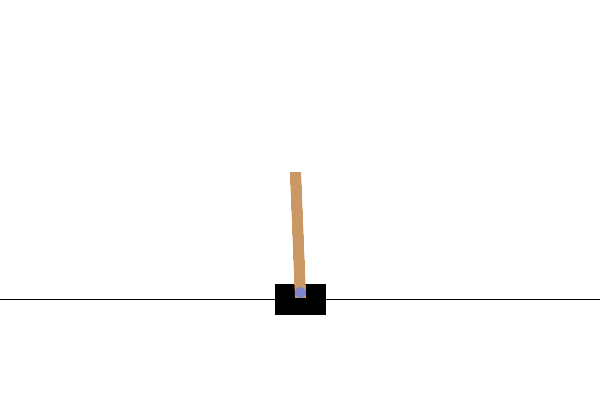

In [ ]:
play_episode("CartPole-v1", policy=None, path="cartpole_random.gif", seed=1, fps=30)

### Return and discounting

The agent doesn't maximise the *next* reward — it maximises the **return** $G_t$, the whole
discounted future:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots = \sum_{k=0}^{\infty}\gamma^{k}R_{t+k+1}, \qquad \gamma\in[0,1).$$

The **discount factor** $\gamma$ sets the horizon: $\gamma\to1$ is far-sighted, $\gamma\to0$ is myopic
(grab the nearest reward). Let's measure the return of a random episode at different $\gamma$.

In [ ]:
def discounted_return(gamma, seed=1, max_t=500):
    o, _ = env.reset(seed=seed)
    G = 0.0
    for t in range(max_t):
        o, r, term, trunc, _ = env.step(0)
        G += (gamma ** t) * r
        if term or trunc:
            break
    return G

for g in [0.5, 0.9, 0.99, 1.0]:
    print(f"gamma={g:<4}  return={discounted_return(g):.2f}")

gamma=0.5   return=2.00
gamma=0.9   return=6.51
gamma=0.99  return=9.56
gamma=1.0   return=10.00


> **✏️ Exercise.** Vary `gamma` between 0 and 1 above. Why does a *small* `gamma` give a much
> smaller return even though the agent balances for the same number of steps?
>
> <details><summary>Solution</summary>
>
> With small `gamma`, rewards far in the future are multiplied by `gamma**t ≈ 0`, so only the
> first few steps count. The agent becomes *myopic*. Large `gamma` values long-term survival —
> exactly what we want for balancing.
> </details>

### Two questions before we can learn

**How to explore?** Acting randomly (above) never improves; always taking what looks best risks
getting stuck. This is the **exploration vs exploitation** trade-off — the central dilemma of
learning from your own experience. In Block 2 we solve it with a dead-simple rule (**ε-greedy**).

![Exploration vs exploitation](https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit1/expexpltradeoff.jpg)

**What to learn?** Two families: **policy-based** (learn the action map directly) and
**value-based** (learn *how good* states/actions are, then act greedily). Today we take the
**value-based** road: **Q-Learning**, then its deep version **DQN**. The bridge between them is one
substitution — store values in a **table**, then replace the table with a **neural network**.

# 2 · Q-Learning — learning a value table

### From values to a policy

A **value** is an expected return — *how good is this situation?*

- **State-value** $V_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t=s]$ — how good is being in $s$.
- **Action-value** $Q_\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t=s, A_t=a]$ — how good is taking $a$ in $s$.

$Q$ is the actionable one: if we know $Q(s,\cdot)$ we get a policy *for free* by acting greedily,
$\pi(s)=\arg\max_a Q(s,a)$ — no model of the environment needed.

### Bellman + TD: how the values get learned

Summing the whole future for every state is wasteful. **Bellman's insight** is recursion —
a value equals the immediate reward plus the discounted value of the *next* state:

$$Q(S_t,A_t) \;=\; R_{t+1} + \gamma \max_a Q(S_{t+1}, a).$$

We don't know the right-hand side, so we **bootstrap**: nudge our current estimate toward it after
each step. This is **Temporal-Difference (TD)** learning, and the **Q-Learning update** is:

$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\Big[\underbrace{R_{t+1} + \gamma \max_a Q(S_{t+1},a)}_{\text{TD target}} - Q(S_t,A_t)\Big].$$

(Contrast with **Monte Carlo**, which waits for the episode to end and uses the *actual* return:
unbiased but high-variance. TD updates every step at the cost of some bias.)

We'll learn this table on **FrozenLake** — a 4×4 grid: walk from start `S` to goal `G` without
falling in a hole `H`. 16 states, 4 actions → a tiny, fully tabulatable Q-table.

states=16, actions=4  ->  Q-table shape = (16, 4)


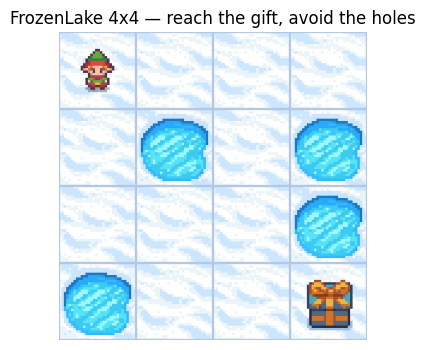

In [ ]:
lake = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
n_states, n_actions = lake.observation_space.n, lake.action_space.n
print(f"states={n_states}, actions={n_actions}  ->  Q-table shape = ({n_states}, {n_actions})")
show_env("FrozenLake-v1", title="FrozenLake 4x4 — reach the gift, avoid the holes",
         map_name="4x4", is_slippery=False)

### ε-greedy: the exploration rule

How does a value-based agent explore? **ε-greedy**: with probability $1-\varepsilon$ take the best
known action ($\arg\max_a Q$), with probability $\varepsilon$ take a random one. Start at
$\varepsilon=1$ (all exploration, the table is empty) and **decay** it as the table sharpens.

In [ ]:
def epsilon_greedy(Q, state, epsilon):
    if rng.random() < epsilon:
        return lake.action_space.sample()      # explore
    return int(np.argmax(Q[state]))            # exploit

def epsilon_decay(epsilon_start, episode, n_episodes):
    return epsilon_start * (1 - episode / n_episodes)

### The training loop

Below is the entire Q-Learning algorithm. The one line that does the learning is
the **Q-update**. It is left blank as an exercise.

In [ ]:
# ✏️ EXERCISE: fill in the single Q-Learning update line (marked TODO).
def train_q_learning(n_episodes=5000, alpha=0.7, gamma=0.95, max_steps=100, epsilon_start=1.0):
    Q = np.zeros((n_states, n_actions))
    returns, snapshots = [], {}
    for ep in range(n_episodes):
        epsilon = epsilon_decay(epsilon_start=epsilon_start, episode=ep, n_episodes=n_episodes)
        state, _ = lake.reset(seed=ep)
        ep_return = 0.0
        for _ in range(max_steps):
            action = epsilon_greedy(Q, state, epsilon)
            next_state, reward, terminated, truncated, _ = lake.step(action)

            # TODO: update Q[state, action] toward the TD target R + gamma * max_a Q[next_state, a]
            Q[state, action] = ...                                          # <-- your line here

            state = next_state
            ep_return += reward
            if terminated or truncated:
                break
        returns.append(ep_return)
        if ep in (0, 50, 200, 1000, n_episodes - 1):
            snapshots[ep] = Q.copy()
    return Q, returns, snapshots

<details><summary>✅ Solution — the Q-update</summary>

```python
Q[state, action] = Q[state, action] + alpha * (
    reward + gamma * np.max(Q[next_state]) - Q[state, action]
)
```
</details>

In [ ]:
np.random.seed(42)

# Reference solution (run this to proceed even if you skipped the exercise).
def train_q_learning(n_episodes=5000, alpha=0.7, gamma=0.95, max_steps=100, epsilon_start=1.0):
    Q = np.zeros((n_states, n_actions))
    returns, snapshots = [], {}
    for ep in range(n_episodes):
        epsilon = epsilon_decay(epsilon_start=epsilon_start, episode=ep, n_episodes=n_episodes)
        state, _ = lake.reset(seed=ep)
        ep_return = 0.0
        for _ in range(max_steps):
            action = epsilon_greedy(Q, state, epsilon)
            next_state, reward, terminated, truncated, _ = lake.step(action)
            Q[state, action] = Q[state, action] + alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )
            state = next_state
            ep_return += reward
            if terminated or truncated:
                break
        returns.append(ep_return)
        if ep in (0, 50, 200, 1000, n_episodes - 1):
            snapshots[ep] = Q.copy()
    return Q, returns, snapshots

Q, returns, snapshots = train_q_learning(epsilon_start=1.0)
print(f"Success rate over last 500 episodes: {np.mean(returns[-500:]):.1%}")

Success rate over last 500 episodes: 96.0%


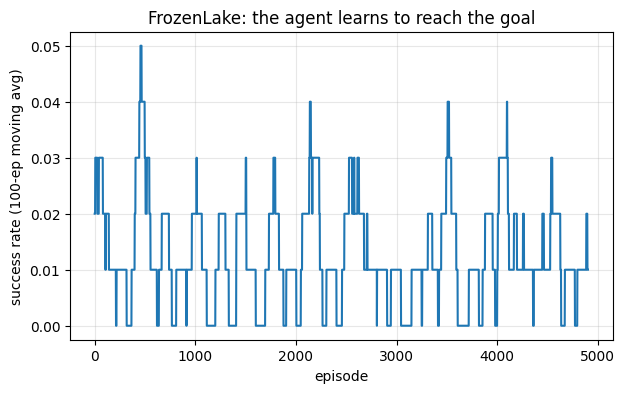

In [ ]:
# Learning curve: fraction of episodes reaching the goal, smoothed.
window = 100
smoothed = np.convolve(returns, np.ones(window) / window, mode="valid")
plt.plot(smoothed)
plt.xlabel("episode"); plt.ylabel(f"success rate ({window}-ep moving avg)")
plt.title("FrozenLake: the agent learns to reach the goal"); plt.grid(alpha=0.3); plt.show()

### Watch value flow *backward*

The magic is the $\gamma\max_a Q(S_{t+1},a)$ term: once the goal has value, it pulls its neighbours
up — even through unrewarded moves. Reshape $\max_a Q(s,\cdot)$ onto the 4×4 grid and watch the
value diffuse from the goal (bottom-right) back to the start across training snapshots.

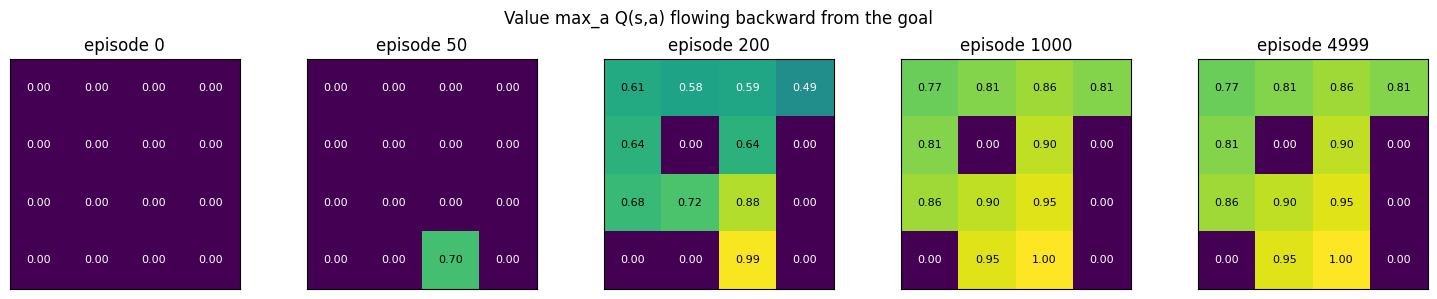

In [ ]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(3 * len(snapshots), 3))
for ax, (ep, Qsnap) in zip(axes, sorted(snapshots.items())):
    V = Qsnap.max(axis=1).reshape(4, 4)
    ax.imshow(V, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"episode {ep}"); ax.set_xticks([]); ax.set_yticks([])
    for (i, j), v in np.ndenumerate(V):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v < 0.6 else "black", fontsize=8)
fig.suptitle("Value max_a Q(s,a) flowing backward from the goal"); plt.tight_layout(); plt.show()

### Watch the trained agent solve the lake

The greedy policy `argmax_a Q(s,a)` should now walk straight from start to goal:

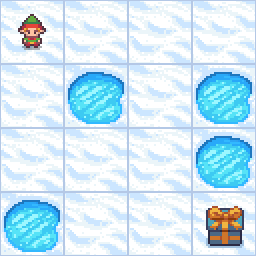

In [ ]:
greedy_policy = lambda state: int(np.argmax(Q[state]))
play_episode("FrozenLake-v1", policy=greedy_policy, path="frozenlake_solved.gif",
             fps=2, max_steps=50, map_name="4x4", is_slippery=False)

> **✏️ Exercise.** Re-run training with the exploration schedule frozen at a tiny `epsilon`
> (e.g. replace the decay line with `epsilon = 0.01`). Does the agent still find the goal reliably? Why?
>
> <details><summary>Solution</summary>
>
> With almost no exploration the agent rarely stumbles onto the goal early, so most cells stay 0 and
> learning stalls or is much slower. Early exploration is what *discovers* the reward that then
> propagates backward. This is the exploration/exploitation trade-off from Block 1, made concrete.
> </details>

**On-policy vs off-policy (one line).** Q-Learning acts with ε-greedy but updates toward the
**greedy** action (`max`). It learns the *optimal* policy's value while exploring — it is
**off-policy**. That property is exactly what lets DQN, next, learn from a buffer of *old* experience.

# 3 · Deep Q-Learning (DQN) — when the table breaks

A Q-table needs one row per state. FrozenLake had 16; our CartPole has a **continuous** state
(four real numbers) → *infinitely* many states. You cannot tabulate it. Atari is worse: a raw frame
has more configurations than there are atoms in the universe.

![Raw pixels → astronomically many states](https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit4/atari.jpg)

The fix: replace the table with a **neural network** $Q(s,a;\theta)$ that *generalises* across
similar states. Same Bellman/TD core — but instead of overwriting a cell, we minimise a **loss**
(prediction vs TD target) by gradient descent. We'll use the battle-tested **Stable-Baselines3**
implementation so we can focus on the ideas.

In [ ]:
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback, CallbackList
from stable_baselines3.common.monitor import Monitor

# Hyperparameters from the RL-Baselines3-Zoo tuned config for CartPole (solves in ~50k steps, ~1-2 min CPU).
model = DQN(
    "MlpPolicy", "CartPole-v1",
    learning_rate=2.3e-3, batch_size=64, gamma=0.99,
    buffer_size=100_000,          # <-- FIX 1: Experience Replay (store & reuse past transitions)
    learning_starts=1000,
    target_update_interval=10,    # <-- FIX 2: Fixed Q-Target (copy weights to a frozen target net)
    train_freq=256, gradient_steps=128,
    exploration_fraction=0.16, exploration_final_eps=0.04,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=0,
)

**The three fixes from the lecture are right here as arguments.** Naively combining a neural net
with bootstrapping is unstable; DQN adds three tricks:

1. **Experience Replay** → `buffer_size`: store transitions and train on random minibatches, which
   reuses data and *decorrelates* consecutive frames.
2. **Fixed Q-Target** → `target_update_interval`: build the TD target from a *frozen copy* of the
   network so we aren't chasing a moving target; refresh it every *C* steps.
3. **Double DQN** → curbs the `max` operator's overestimation by using two networks to *select* vs
   *evaluate* the next action. *(Note: SB3's stock `DQN` does **not** enable Double DQN — it's a
   conceptual refinement here, available in extensions.)*

**Why we keep the *best* checkpoint.** Combining a neural net with bootstrapping is unstable —
DQN often climbs to a high score and then *catastrophically forgets*, so the **final** weights
aren't necessarily good. We therefore evaluate the greedy policy every few thousand steps with an
`EvalCallback`, save the **best** model, and report/animate that. (This is exactly how RL-Zoo gets
its headline ~500 score, and why the final-weights reward can look much worse than the peak.)

In [ ]:
# Logger for the BEHAVIOUR policy: rolling mean of the (ε-greedy) episode rewards seen during training.
class RewardLogger(BaseCallback):
    def __init__(self): super().__init__(); self.steps, self.rewards = [], []
    def _on_step(self):
        if self.model.ep_info_buffer:
            self.steps.append(self.num_timesteps)
            self.rewards.append(np.mean([e["r"] for e in self.model.ep_info_buffer]))
        return True

# Evaluate the GREEDY policy periodically on a separate env and keep the best checkpoint.
eval_env = Monitor(gym.make("CartPole-v1"))
eval_callback = EvalCallback(
    eval_env, best_model_save_path="logs/", log_path="logs/",
    eval_freq=5000, n_eval_episodes=10, deterministic=True, verbose=0,
)
behaviour_logger = RewardLogger()

# Score + record the UNTRAINED agent...
untrained_policy = lambda obs: int(model.predict(obs, deterministic=True)[0])
mean_before, _ = evaluate_policy(model, eval_env, n_eval_episodes=10)
print(f"Before training: mean reward = {mean_before:.1f} (max possible = 500)")
before_gif = play_episode("CartPole-v1", policy=untrained_policy, path="cartpole_before.gif", fps=30)

# ...train (~1-2 min on CPU); evaluate every 5000 steps, save the best model, log behaviour reward...
model.learn(total_timesteps=50_000, callback=CallbackList([eval_callback, behaviour_logger]))

# ...load the BEST checkpoint (not the final weights) and score + record it.
best_model = DQN.load("logs/best_model")
trained_policy = lambda obs: int(best_model.predict(obs, deterministic=True)[0])
mean_after, std_after = evaluate_policy(best_model, eval_env, n_eval_episodes=10)
print(f"Best checkpoint: mean reward = {mean_after:.1f} +/- {std_after:.1f}")
after_gif = play_episode("CartPole-v1", policy=trained_policy, path="cartpole_after.gif", fps=30)

Before training: mean reward = 9.5 (max possible = 500)
Best checkpoint: mean reward = 500.0 +/- 0.0


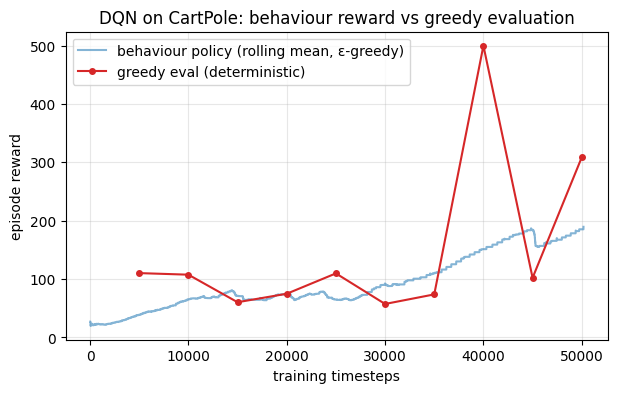

In [ ]:
# Overlay the two views: the lagging behaviour-policy rolling mean vs the true greedy evaluation.
eval_timesteps = eval_callback.evaluations_timesteps
eval_rewards = np.array(eval_callback.evaluations_results).mean(axis=1)
plt.plot(behaviour_logger.steps, behaviour_logger.rewards,
         alpha=0.55, label="behaviour policy (rolling mean, ε-greedy)")
plt.plot(eval_timesteps, eval_rewards, marker="o", ms=4, color="C3",
         label="greedy eval (deterministic)")
plt.xlabel("training timesteps"); plt.ylabel("episode reward")
plt.title("DQN on CartPole: behaviour reward vs greedy evaluation")
plt.legend(); plt.grid(alpha=0.3); plt.show()

### Before vs after training

BEFORE — untrained network flails:


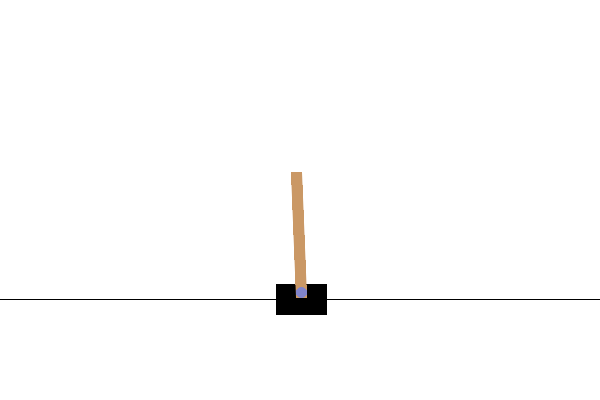

AFTER  — trained agent balances the pole:


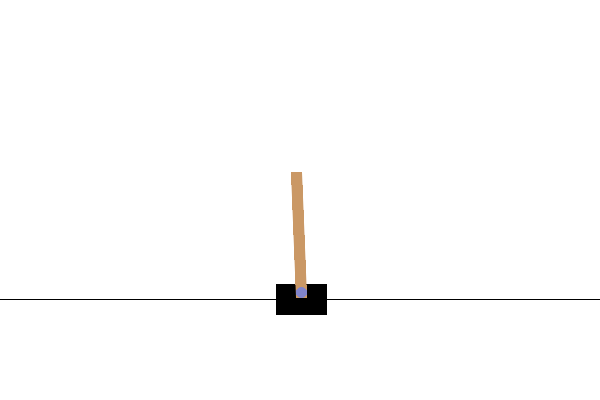

In [ ]:
print("BEFORE — untrained network flails:");   display(before_gif)
print("AFTER  — trained agent balances the pole:"); display(after_gif)

# Wrap-up

You ran the whole lecture:

- **Framework** — the state→action→reward loop, return, discounting, exploration vs exploitation.
- **Q-Learning** — a value **table** learned by TD; value flows backward from the goal.
- **DQN** — swap the table for a **neural network**, stabilised by replay + a fixed target.

The conceptual spine (Bellman recursion + TD bootstrapping) never changed — we only changed *how
values are stored and updated*.

### Where this goes next
- **Policy-gradient** methods learn the policy directly and handle **continuous** actions.
- **Actor–Critic / PPO** — the robust modern workhorse… and the algorithm behind **RLHF** for LLMs.

We took the *value-based* road today; the *policy-based* road is the other half of the map.

### 🚀 Outlook: a deep agent at scale (optional)

CartPole is deliberately simple. The same `DQN` code, given a harder environment, learns to land a
rocket. Below we install **Box2D** and load a *pretrained* Lunar Lander agent from the Hugging Face
Hub (training it from scratch would take longer than a lecture slot), then watch it play.

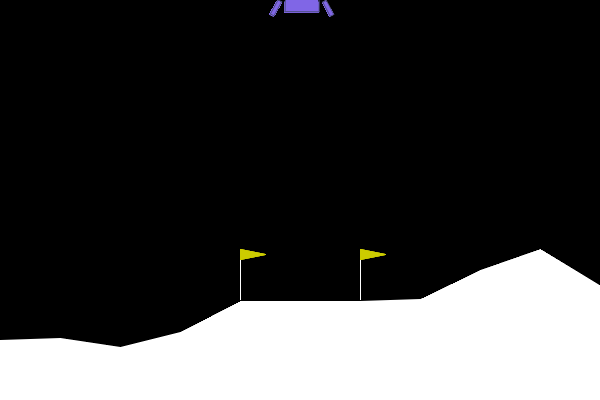

In [ ]:
# shimmy bridges the old-Gym spaces in the pretrained checkpoint to modern Gymnasium/SB3.
%pip install -q "gymnasium[box2d]" huggingface_sb3 "shimmy>=0.2.1"

from huggingface_sb3 import load_from_hub
checkpoint = load_from_hub("sb3/dqn-LunarLander-v2", "dqn-LunarLander-v2.zip")
lander = DQN.load(checkpoint)
lander_policy = lambda obs: int(lander.predict(obs, deterministic=True)[0])
display(play_episode("LunarLander-v3", policy=lander_policy, path="lander.gif", fps=30))

### If you are interested: try the Hugging Face course
🔗 <https://huggingface.co/learn/deep-rl-course>

---
Some content was adapted from the **Hugging Face Deep RL Course** (Thomas Simonini & Omar Sanseviero),
<https://github.com/huggingface/deep-rl-class> — **Apache-2.0**. Figures © Hugging Face, reused with attribution.